## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Load the Data

In [2]:
df = pd.read_csv("../data/dataset.csv")   # use your file name

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Overview of Data

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB
None


## check Missing Values

In [4]:
display("\nMissing Values")
display(df.isnull().sum())

'\nMissing Values'

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

## Check value Counts

In [5]:
display("\nDisease Distribution")
display(df['Disease'].value_counts())

'\nDisease Distribution'

Disease
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
Aller

## Fill Missing values

In [6]:
df = df.fillna("none")

In [7]:
df["Symptoms"] = df.iloc[:,1:].apply(lambda x: " ".join(x), axis=1)

df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,Symptoms
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,none,none,none,none,none,none,none,none,none,none,none,none,none,itching skin_rash nodal_skin_eruptions disc...
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,none,none,none,none,none,none,none,none,none,none,none,none,none,none,skin_rash nodal_skin_eruptions dischromic _...
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,none,none,none,none,none,none,none,none,none,none,none,none,none,none,itching nodal_skin_eruptions dischromic _pat...
3,Fungal infection,itching,skin_rash,dischromic _patches,none,none,none,none,none,none,none,none,none,none,none,none,none,none,itching skin_rash dischromic _patches none n...
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,none,none,none,none,none,none,none,none,none,none,none,none,none,none,itching skin_rash nodal_skin_eruptions none ...


## Label Encoding

In [8]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Disease"])

joblib.dump(label_encoder,"disease_label_encoder.pkl")

['disease_label_encoder.pkl']

## Tokenization

In [9]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(df["Symptoms"])

X = tokenizer.texts_to_sequences(df["Symptoms"])

X = pad_sequences(X)

joblib.dump(tokenizer,"symptom_tokenizer.pkl")

print("Feature Shape:", X.shape)

Feature Shape: (4920, 30)


## Split the Data into Train/ Test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (3936, 30)
Test Shape: (984, 30)


## Build the Model

In [11]:
vocab_size = len(tokenizer.word_index) + 1

model = Sequential()

model.add(Embedding(input_dim=vocab_size,
                    output_dim=64,
                    input_length=X.shape[1]))

model.add(Conv1D(filters=64,
                 kernel_size=3,
                 activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 30, 64)            13440     
                                                                 
 conv1d (Conv1D)             (None, 28, 64)            12352     
                                                                 
 max_pooling1d (MaxPooling1  (None, 14, 64)            0         
 D)                                                              
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                     

## Train the Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10


123/123 [==============================] - 9s 36ms/step - loss: 2.8872 - accuracy: 0.2071 - val_loss: 1.3594 - val_accuracy: 0.6921
Epoch 2/10
123/123 [==============================] - 4s 30ms/step - loss: 0.7275 - accuracy: 0.8298 - val_loss: 0.2143 - val_accuracy: 0.9970
Epoch 3/10
123/123 [==============================] - 2s 15ms/step - loss: 0.1970 - accuracy: 0.9825 - val_loss: 0.0416 - val_accuracy: 1.0000
Epoch 4/10
123/123 [==============================] - 3s 24ms/step - loss: 0.0665 - accuracy: 0.9977 - val_loss: 0.0135 - val_accuracy: 1.0000
Epoch 5/10
123/123 [==============================] - 2s 17ms/step - loss: 0.0337 - accuracy: 1.0000 - val_loss: 0.0072 - val_accuracy: 1.0000
Epoch 6/10
123/123 [==============================] - 3s 25ms/step - loss: 0.0214 - accuracy: 0.9995 - val_loss: 0.0038 - val_accuracy: 1.0000
Epoch 7/10
123/123 [==============================] - 2s 17ms/step - loss: 0.0163 - accuracy: 0.9997 - val_loss: 0.0024 - val_accuracy: 1.00

## Accuracy

In [13]:
pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

accuracy = accuracy_score(y_test,pred)

error = 1 - accuracy

print("Accuracy:",accuracy)
print("Error:",error)

31/31 [==============================] - 1s 12ms/step
Accuracy: 1.0
Error: 0.0


## Model Accuracy Graph

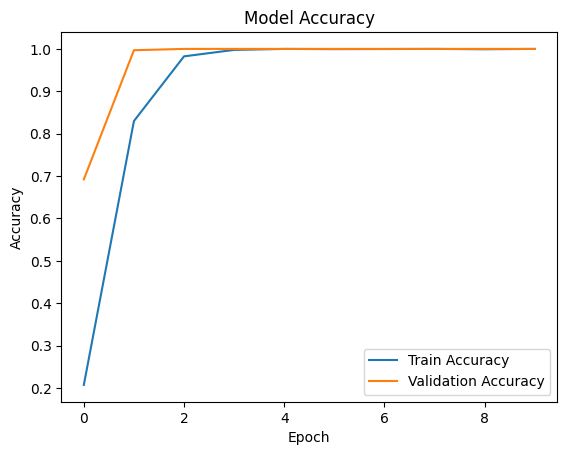

In [14]:
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()